<a href="https://colab.research.google.com/github/xhroch01/MPA-MLF/blob/main/Project_MLF_Knob_Hroch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MLF projekt**

**Import libraries, connect Google Drive, load and sort training data by ID**

In [14]:
!pip install -q -U keras-tuner
import numpy as np
import pandas as pd
import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import re
import random

In [15]:
from google.colab import drive
drive.mount('/content/drive')

# Path to the data folder in Google Drive
data_dir = '/content/drive/MyDrive/MPA-MLF_DATA_NEW'

# Loading and sorting training files by ID
train_files = sorted(glob.glob(f'{data_dir}/Train/*.npy'),
                     key=lambda x: int(x.split('/')[-1].split('.')[0]))

# Loading training data
X = np.array([np.load(f) for f in train_files])
print("Training data shape:", X.shape)

# Loading labels
labels_df = pd.read_csv(f'{data_dir}/label_train.csv')
print(labels_df.head())
print("Columns in the file:", labels_df.columns)

# Retrieving labels from the 'target' column
y = labels_df['target'].values
print("Number of labels:", len(y))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training data shape: (1491, 72, 48)
   ID  target
0   0       0
1   1       0
2   2       0
3   3       0
4   4       0
Columns in the file: Index(['ID', 'target'], dtype='object')
Number of labels: 1491


**Data normalization and preprocessing - splitting into training and validation sets**

In [16]:
# Normalization of each sample separately (standardization to mean 0, std 1)
X = (X - X.mean(axis=(1,2), keepdims=True)) / X.std(axis=(1,2), keepdims=True)

# Split into training and validation sets (80% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Number of training samples:", X_train.shape[0])
print("Number of validation samples:", X_val.shape[0])

# Adding a channel dimension (for CNN) – z (72, 48) → (72, 48, 1)
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]

# One-hot encoding of labels (for 3 classes)
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat   = to_categorical(y_val, num_classes=3)


Number of training samples: 1192
Number of validation samples: 299


In [20]:
def build_model(hp):
    model = models.Sequential()

    # Convolutional layers (fixed)
    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(72,48,1),
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(LeakyReLU(alpha=0.1))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(LeakyReLU(alpha=0.1))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Dense layer
    model.add(layers.Flatten())
    dense_units = hp.Int('dense_units', min_value=128, max_value=512, step=64)
    model.add(layers.Dense(dense_units, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(LeakyReLU(alpha=0.1))

    # Dropout
    dropout_rate = hp.Float('dropout', min_value=0.4, max_value=0.7, step=0.1)
    model.add(layers.Dropout(dropout_rate))

    # Output layer
    model.add(layers.Dense(3, activation='softmax'))

    # Learning rate
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


In [21]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory='my_dir',
    project_name='cnn_tuning'
)

# Overview of possible parameters
tuner.search_space_summary()

# Tuning
tuner.search(X_train, y_train_cat,
             validation_data=(X_val, y_val_cat),
             epochs=20,
             batch_size=32,
             verbose=2)

# Best model
best_model = tuner.get_best_models(num_models=1)[0]
tuner.results_summary()
best_model.summary()

Trial 10 Complete [00h 00m 24s]
val_accuracy: 0.9498327970504761

Best val_accuracy So Far: 0.9933110475540161
Total elapsed time: 00h 04m 38s
Results summary
Results in my_dir/cnn_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 00 summary
Hyperparameters:
dense_units: 384
dropout: 0.4
learning_rate: 0.0011910703642278476
Score: 0.9933110475540161

Trial 05 summary
Hyperparameters:
dense_units: 256
dropout: 0.4
learning_rate: 0.005044806672551905
Score: 0.9933110475540161

Trial 08 summary
Hyperparameters:
dense_units: 192
dropout: 0.6000000000000001
learning_rate: 0.0024855477006379316
Score: 0.9933110475540161

Trial 01 summary
Hyperparameters:
dense_units: 384
dropout: 0.4
learning_rate: 0.0029860644714577917
Score: 0.9899665713310242

Trial 04 summary
Hyperparameters:
dense_units: 512
dropout: 0.4
learning_rate: 0.009726251164538662
Score: 0.9899665713310242

Trial 09 summary
Hyperparameters:
dense_units: 128
dropout: 0.5
learning_rate: 0.000775

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 72, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 72, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 72, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 36, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 36, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 13824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │     5,308,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,155 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,330,691 (20.33 MB)

 Trainable params: 5,329,731 (20.33 MB)

 Non-trainable params: 960 (3.75 KB)

**Definition of Convolutional Neural Network (CNN) Architecture and Model Compilation**

In [22]:
# CNN model definition
model = models.Sequential()

# 1st convolution block
model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(72,48,1),
                        kernel_regularizer=regularizers.l2(1e-4)))
model.add(layers.BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# 2nd convolution block
model.add(layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
model.add(layers.BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Dense block
model.add(layers.Flatten())
model.add(layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)))
model.add(layers.BatchNormalization())
model.add(layers.LeakyReLU(alpha=0.1))
model.add(layers.Dropout(0.6))

# Output layer
model.add(layers.Dense(3, activation='softmax'))

# Model compilation
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Architecture summary listing
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 72, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 72, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 72, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 36, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 36, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 36, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 36, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 36, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 18, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 13824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,769,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,789,699 (6.83 MB)

 Trainable params: 1,789,251 (6.83 MB)

 Non-trainable params: 448 (1.75 KB)

**Training the model**

In [23]:
# Checkpoint – saves the model with the best validation loss
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss',
                             save_best_only=True, verbose=1)

# Model training
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint],
    verbose=2
)

Epoch 1/50

Epoch 1: val_loss improved from inf to 5.22798, saving model to best_model.h5


38/38 - 14s - 371ms/step - accuracy: 0.8540 - loss: 0.4191 - val_accuracy: 0.0936 - val_loss: 5.2280
Epoch 2/50

Epoch 2: val_loss did not improve from 5.22798
38/38 - 0s - 13ms/step - accuracy: 0.9530 - loss: 0.1833 - val_accuracy: 0.0936 - val_loss: 10.3346
Epoch 3/50

Epoch 3: val_loss did not improve from 5.22798
38/38 - 0s - 10ms/step - accuracy: 0.9748 - loss: 0.1236 - val_accuracy: 0.1338 - val_loss: 12.4059
Epoch 4/50

Epoch 4: val_loss did not improve from 5.22798
38/38 - 0s - 12ms/step - accuracy: 0.9832 - loss: 0.1045 - val_accuracy: 0.1405 - val_loss: 13.2946
Epoch 5/50

Epoch 5: val_loss did not improve from 5.22798
38/38 - 0s - 10ms/step - accuracy: 0.9815 - loss: 0.1130 - val_accuracy: 0.0936 - val_loss: 13.7060
Epoch 6/50

Epoch 6: val_loss did not improve from 5.22798
38/38 - 1s - 17ms/step - accuracy: 0.9899 - loss: 0.0875 - val_accuracy: 0.1739 - val_loss: 13.6506
Epoch 7/50

Epoch 7: val_loss did not improve from 5.22798
38/38 - 0s - 10ms/step - accuracy: 0.9883 - l

38/38 - 0s - 10ms/step - accuracy: 0.9950 - loss: 0.0788 - val_accuracy: 0.1873 - val_loss: 4.0553
Epoch 14/50

Epoch 14: val_loss improved from 4.05534 to 2.18719, saving model to best_model.h5


38/38 - 0s - 11ms/step - accuracy: 0.9966 - loss: 0.0749 - val_accuracy: 0.2709 - val_loss: 2.1872
Epoch 15/50

Epoch 15: val_loss improved from 2.18719 to 1.76354, saving model to best_model.h5


38/38 - 0s - 10ms/step - accuracy: 0.9966 - loss: 0.0731 - val_accuracy: 0.3110 - val_loss: 1.7635
Epoch 16/50

Epoch 16: val_loss did not improve from 1.76354
38/38 - 0s - 8ms/step - accuracy: 0.9933 - loss: 0.0759 - val_accuracy: 0.2274 - val_loss: 2.3775
Epoch 17/50

Epoch 17: val_loss improved from 1.76354 to 1.35533, saving model to best_model.h5


38/38 - 1s - 19ms/step - accuracy: 0.9966 - loss: 0.0683 - val_accuracy: 0.3980 - val_loss: 1.3553
Epoch 18/50

Epoch 18: val_loss improved from 1.35533 to 0.25549, saving model to best_model.h5


38/38 - 0s - 11ms/step - accuracy: 0.9983 - loss: 0.0663 - val_accuracy: 0.9331 - val_loss: 0.2555
Epoch 19/50

Epoch 19: val_loss improved from 0.25549 to 0.20378, saving model to best_model.h5


38/38 - 1s - 16ms/step - accuracy: 0.9966 - loss: 0.0689 - val_accuracy: 0.9532 - val_loss: 0.2038
Epoch 20/50

Epoch 20: val_loss did not improve from 0.20378
38/38 - 0s - 8ms/step - accuracy: 0.9941 - loss: 0.0751 - val_accuracy: 0.8796 - val_loss: 0.3621
Epoch 21/50

Epoch 21: val_loss improved from 0.20378 to 0.15211, saving model to best_model.h5


38/38 - 0s - 10ms/step - accuracy: 0.9950 - loss: 0.0732 - val_accuracy: 0.9799 - val_loss: 0.1521
Epoch 22/50

Epoch 22: val_loss improved from 0.15211 to 0.08960, saving model to best_model.h5


38/38 - 1s - 16ms/step - accuracy: 0.9950 - loss: 0.0755 - val_accuracy: 0.9833 - val_loss: 0.0896
Epoch 23/50

Epoch 23: val_loss did not improve from 0.08960
38/38 - 1s - 14ms/step - accuracy: 0.9899 - loss: 0.0904 - val_accuracy: 0.9900 - val_loss: 0.1126
Epoch 24/50

Epoch 24: val_loss did not improve from 0.08960
38/38 - 0s - 8ms/step - accuracy: 0.9992 - loss: 0.0783 - val_accuracy: 0.9900 - val_loss: 0.1124
Epoch 25/50

Epoch 25: val_loss did not improve from 0.08960
38/38 - 1s - 16ms/step - accuracy: 0.9983 - loss: 0.0785 - val_accuracy: 0.9799 - val_loss: 0.1393
Epoch 26/50

Epoch 26: val_loss did not improve from 0.08960
38/38 - 0s - 8ms/step - accuracy: 0.9966 - loss: 0.0809 - val_accuracy: 0.9833 - val_loss: 0.1425
Epoch 27/50

Epoch 27: val_loss did not improve from 0.08960
38/38 - 0s - 8ms/step - accuracy: 0.9983 - loss: 0.0774 - val_accuracy: 0.9699 - val_loss: 0.1923
Epoch 28/50

Epoch 28: val_loss did not improve from 0.08960
38/38 - 1s - 16ms/step - accuracy: 0.9958 -

**Training and validation loss and accuracy graphs**

Final validation accuracy: 99.33 %


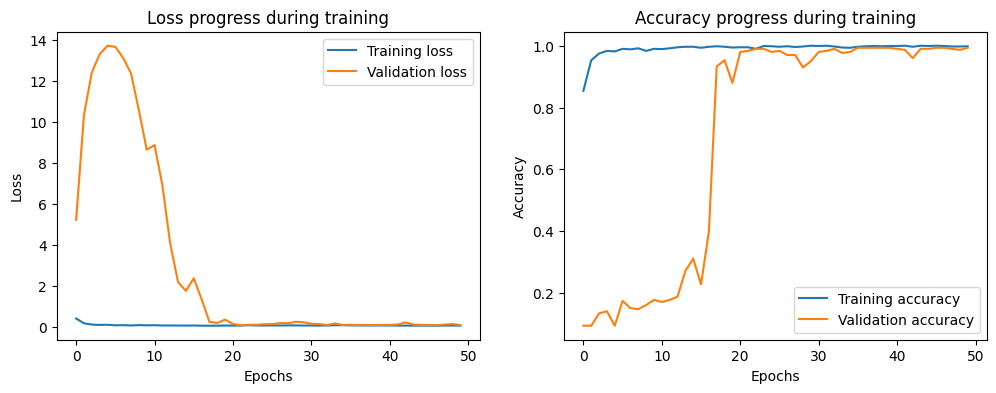

In [24]:
# Final validation accuracy statement in percent
final_val_acc = history.history['val_accuracy'][-1] * 100
print(f"Final validation accuracy: {final_val_acc:.2f} %")

# Plotting training and validation loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss progress during training')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy progress during training')
plt.legend()
plt.show()

**Model evaluation on the validation set – confusion matrix and F1 score**

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


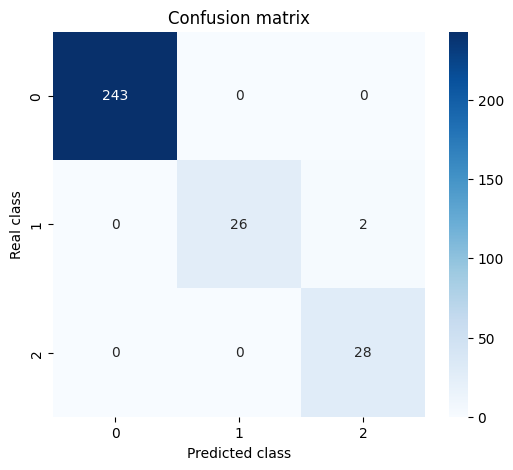

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       243
           1     1.0000    0.9286    0.9630        28
           2     0.9333    1.0000    0.9655        28

    accuracy                         0.9933       299
   macro avg     0.9778    0.9762    0.9762       299
weighted avg     0.9938    0.9933    0.9933       299



In [25]:
# Class probabilities prediction
y_val_pred_probs = model.predict(X_val)

# The most likely class for each sample
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plotting the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel('Predicted class')
plt.ylabel('Real class')
plt.title('Confusion matrix')
plt.show()

# Classification report
print("Classification report:")
print(classification_report(y_val, y_val_pred, digits=4))


**Loading and preprocessing test data**

In [26]:
# Filtering and sorting only those files that have a name in the format number.npy
test_files = glob.glob(f'{data_dir}/Test/*.npy')
test_files = sorted(
    [f for f in test_files if re.fullmatch(r".*/\d+\.npy", f)],
    key=lambda x: int(x.split('/')[-1].split('.')[0])
)

# Loading test data
X_test = np.array([np.load(f) for f in test_files])

# Normalization
X_test = (X_test - X_test.mean(axis=(1,2), keepdims=True)) / X_test.std(axis=(1,2), keepdims=True)

# Add a channel dimension
X_test = X_test[..., np.newaxis]

print("Test data shape:", X_test.shape)


Test data shape: (120, 72, 48, 1)


**Visualization of samples from the test set**

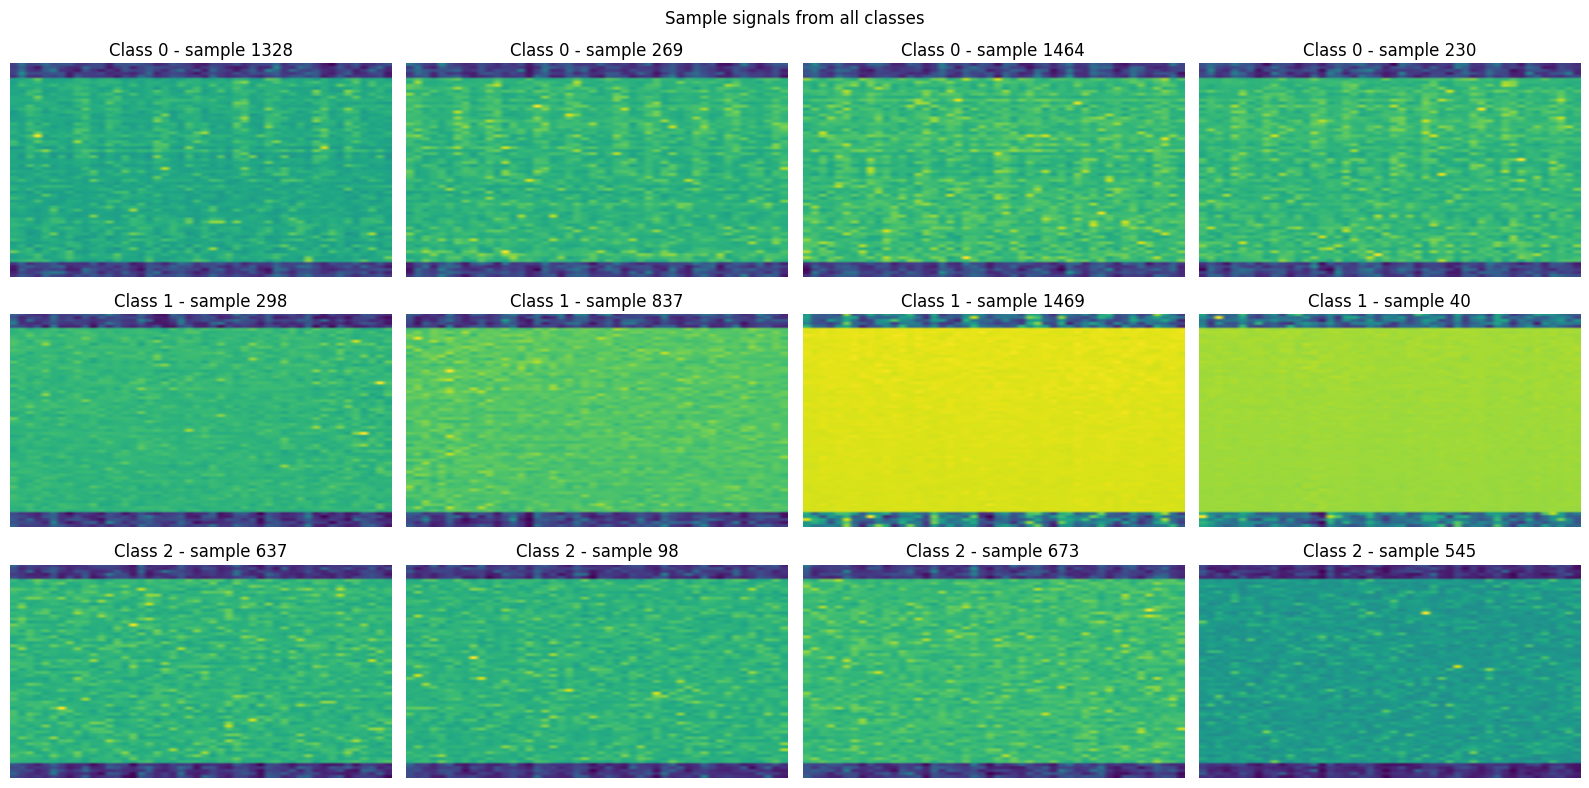

In [27]:
fig, axs = plt.subplots(3, 4, figsize=(16, 8))

for class_label in range(3):
    class_indices = np.where(y == class_label)[0]
    random_samples = random.sample(list(class_indices), 4)

    for i, idx in enumerate(random_samples):
        ax = axs[class_label, i]
        ax.imshow(X[idx], cmap='viridis', aspect='auto')
        ax.set_title(f"Class {class_label} - sample {idx}")
        ax.axis('off')

plt.suptitle("Sample signals from all classes")
plt.tight_layout()
plt.show()


**Prediction on test data using a trained model + creation of a file for submission**

In [28]:
# Probability prediction
y_test_pred_probs = model.predict(X_test)

# The most likely class for each sample
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

# Loading test_format.csv – to maintain correct order ID
test_format = pd.read_csv(f'{data_dir}/test_format.csv')

# Creating a submission dataframe
submission_df = test_format.copy()
submission_df['target'] = y_test_pred

# Export to CSV
submission_df.to_csv('submission.csv', index=False)
print("The submission.csv file has been created.")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
The submission.csv file has been created.
